1. Przygotowanie i Eksploracja Danych (EDA)

W tej sekcji importujemy niezbędne biblioteki, pobieramy zbiór obrazów **CIFAR-10** oraz przygotowujemy tzw. `DataLoadery`, które będą dawkować nasze dane podczas uczenia sieci. 

Dokonujemy również podstawowej transformacji: `ToTensor()` zamienia surowe obrazki (w formacie PIL) na wielowymiarowe macierze (Tensory) zrozumiałe dla PyTorcha, a przy okazji skaluje wartości pikseli z zakresu [0, 255] do [0.0, 1.0]. Następnie stosujemy `Normalize`, aby przesunąć wartości pikseli do zakresu [-1.0, 1.0], co pomaga sieci neuronowej szybciej i stabilniej się uczyć.

In [1]:

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) 
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck')

c:\Users\Kacper\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Analiza zbioru danych (Statystyki)

Zanim przejdziemy do budowy sieci, sprawdzamy podstawowe statystyki zbioru: jego rozmiar, wymiary pojedynczych obrazów oraz zakres wartości pikseli.

In [2]:
print(f"Liczba zdjęć w zbiorze treningowym: {len(train_dataset)}")
print(f"Liczba zdjęć w zbiorze testowym: {len(test_dataset)}\n")

sample_image, sample_label = train_dataset[0]

print(f"Wymiary pojedynczego tensora (obrazka): {sample_image.shape}")
print(f"Nazwa klasy dla pierwszego zdjęcia: {classes[sample_label]}")


print(f"Minimalna wartość piksela: {sample_image.min().item():.2f}")
print(f"Maksymalna wartość piksela: {sample_image.max().item():.2f}")

Liczba zdjęć w zbiorze treningowym: 50000
Liczba zdjęć w zbiorze testowym: 10000

Wymiary pojedynczego tensora (obrazka): torch.Size([3, 32, 32])
Nazwa klasy dla pierwszego zdjęcia: frog
Minimalna wartość piksela: -1.00
Maksymalna wartość piksela: 1.00


Rozkład klas w zbiorze

Dla pewności, że model nie będzie faworyzował żadnej z kategorii, musimy sprawdzić, czy zbiór danych jest zbalansowany. Wykorzystamy do tego wykres słupkowy.

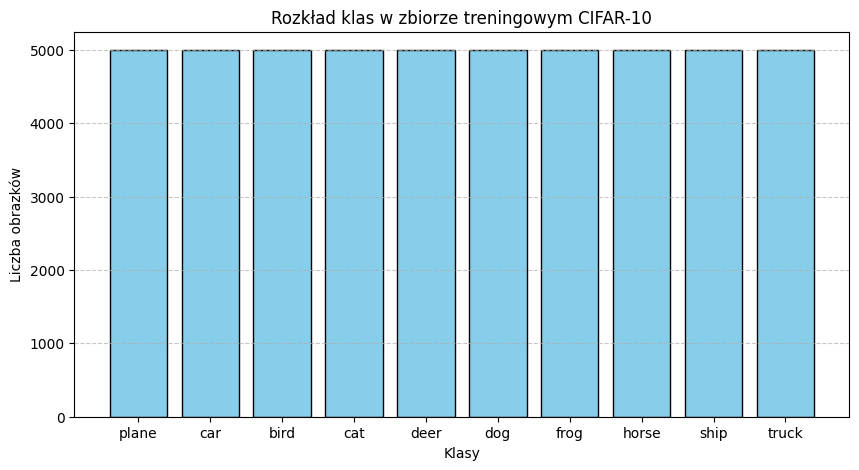

In [3]:
class_counts = Counter(train_dataset.targets)

labels = [classes[i] for i in range(len(classes))]
counts = [class_counts[i] for i in range(len(classes))]

plt.figure(figsize=(10, 5))
plt.bar(labels, counts, color='skyblue', edgecolor='black')
plt.title('Rozkład klas w zbiorze treningowym CIFAR-10')
plt.xlabel('Klasy')
plt.ylabel('Liczba obrazków')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Wizualizacja przykładowych obrazów

Ostatnim elementem analizy jest wyświetlenie przykładowych danych, na których uczyć się będzie nasza Sieć Konwolucyjna. Ponieważ obrazki zostały znormalizowane (wartości od -1 do 1), musimy je odwrócić (tzw. un-normalize), aby matplotlib wyświetlił je poprawnie w oryginalnych kolorach.

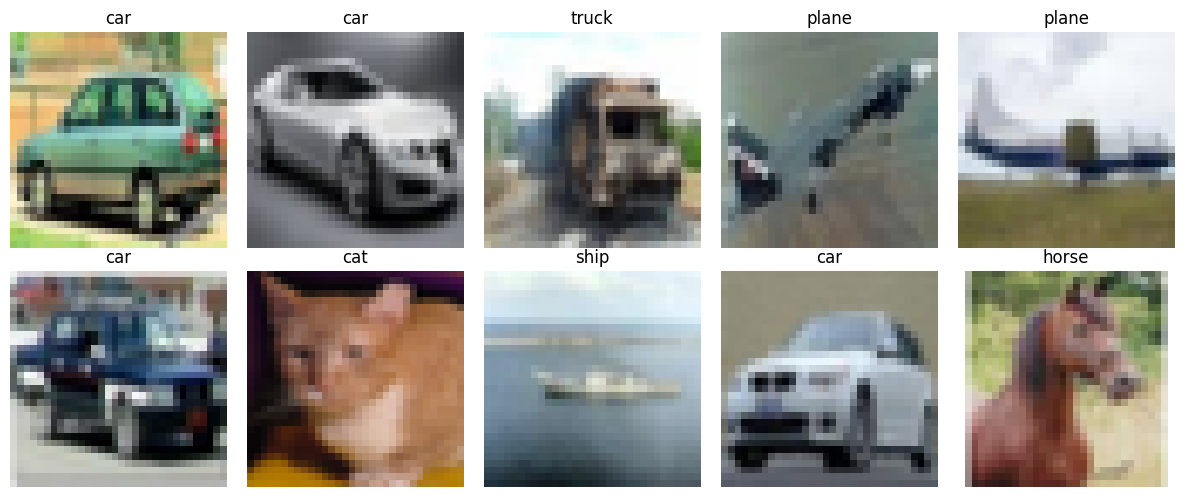

In [4]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off') 

fig = plt.figure(figsize=(12, 5))

for i in range(10):
    ax = fig.add_subplot(2, 5, i+1)
    imshow(images[i])
    ax.set_title(classes[labels[i]])

plt.tight_layout()
plt.show()

2. Definicja architektury Sieci Konwolucyjnej (CNN)


Opis Architektury:
Nasza sieć składa się z dwóch głównych bloków:
1.  **Blok Ekstrakcji Cech:**
    *   **Konwolucja 1:** Filtruje obraz wejściowy (3 kanały RGB). Zastosowano filtr o rozmiarze 3x3. Posiada 16 "filtrów" szukających podstawowych cech.
    *   **Aktywacja ReLU:** Wprowadza nieliniowość.
    *   **Max Pooling 1:** Redukuje wymiary przestrzenne o połowę (skalowanie 2x2).
    *   **Konwolucja 2:** Przetwarza głębiej mapy cech z pierwszej warstwy. Wykorzystuje 32 filtry o rozmiarze 3x3. Zwiększenie liczby filtrów pozwala na wykrywanie bardziej skomplikowanych wzorców.
    *   **Aktywacja ReLU:** Ponownie wprowadza nieliniowość.
    *   **Max Pooling 2:** Ponownie redukuje wymiary. Po tym etapie obrazek 32x32 został zredukowany do wymiarów 8x8 (ale za to z głębokością 32 filtrów).
2.  **Blok Klasyfikacji:**
    *   Po spłaszczeniu danych (Flatten) ze struktury 3D do 1D, otrzymujemy wektor o długości `32 * 8 * 8 = 2048` elementów.
    *   **Warstwa Liniowa (Linear 1):** Zmniejsza wektor do 128 "neuronów".
    *   **Warstwa Liniowa (Linear 2):** Warstwa wyjściowa - dopasowuje wynik do 10 klas naszego problemu CIFAR-10.

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1) 
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3) 
        
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10) 

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) 
        x = F.relu(self.fc1(x))
        x = self.fc2(x) 
        return x

model = SimpleCNN()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)


3. Proces Uczenia Sieci (Training Loop)

Poniższy kod realizuje właściwy proces uczenia. Trening odbywa się w "epokach". Zdefiniujemy pętlę na 5 epok, aby zaobserwować proces nauki, ale jednocześnie nie czekać zbyt długo na wyniki pierwszych testów.

W każdym kroku pętli:
1. Przekazujemy paczkę obrazów do sieci.
2. Sieć generuje swoje przewidywania.
3. Obliczamy błąd za pomocą zdefiniowanej wcześniej funkcji straty (`criterion`).
4. Uruchamiamy wsteczną propagację błędu (`loss.backward()`), która liczy gradienty.
5. Optymalizator (`optimizer.step()`) aktualizuje wagi w sieci na podstawie policzonych gradientów.

Zapisujemy również historię straty i dokładności dla każdej epoki, aby móc potem narysować wykres wymagany w zadaniu.

In [6]:
epochs = 5

train_losses = []
train_accuracies = []
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")

model.to(device)

print(f"Trening na {epochs} epok z Learning Rate = 0.001...")

for epoch in range(epochs):
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        
        loss = criterion(outputs, labels)
        
        loss.backward()
        
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct_predictions / total_samples
    
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)
    
    print(f'Epoka [{epoch + 1}/{epochs}] | Loss: {epoch_loss:.4f} | Accuracy: {epoch_accuracy:.2f}%')


Używane urządzenie: cpu
Trening na 5 epok z Learning Rate = 0.001...
Epoka [1/5] | Loss: 1.3714 | Accuracy: 50.73%
Epoka [2/5] | Loss: 1.0137 | Accuracy: 64.17%
Epoka [3/5] | Loss: 0.8706 | Accuracy: 69.33%
Epoka [4/5] | Loss: 0.7686 | Accuracy: 73.01%
Epoka [5/5] | Loss: 0.6866 | Accuracy: 75.87%


Wizualizacja Krzywych Uczenia

Aby lepiej zrozumieć przebieg treningu modelu, generujemy wykresy krzywych uczenia. 
Na lewym wykresie obserwujemy spadek funkcji straty, co oznacza, że model popełnia mniejsze błędy. Na prawym wykresie widzimy wzrost dokładności, czyli odsetka poprawnie sklasyfikowanych obrazów z danych treningowych.

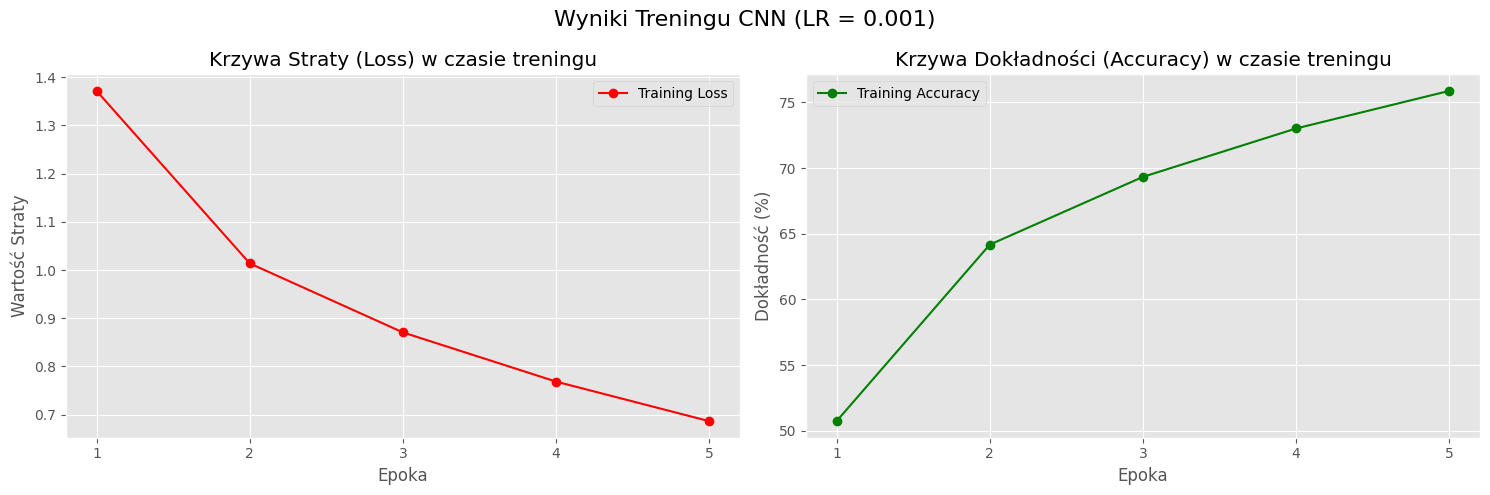

In [7]:
plt.style.use('ggplot')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(range(1, epochs + 1), train_losses, marker='o', color='red', label='Training Loss')
ax1.set_title('Krzywa Straty (Loss) w czasie treningu')
ax1.set_xlabel('Epoka')
ax1.set_ylabel('Wartość Straty')
ax1.set_xticks(range(1, epochs + 1)) 
ax1.legend()

ax2.plot(range(1, epochs + 1), train_accuracies, marker='o', color='green', label='Training Accuracy')
ax2.set_title('Krzywa Dokładności (Accuracy) w czasie treningu')
ax2.set_xlabel('Epoka')
ax2.set_ylabel('Dokładność (%)')
ax2.set_xticks(range(1, epochs + 1))
ax2.legend()

fig.suptitle('Wyniki Treningu CNN (LR = 0.001)', fontsize=16)
plt.tight_layout()
plt.show()

4. Ewaluacja modelu na danych testowych

Najważniejszym sprawdzianem dla sieci neuronowej jest jej skuteczność na danych, których nigdy wcześniej nie widziała. W tym kroku przepuszczamy przez nasz wytrenowany model zbiór testowy (10 000 obrazków CIFAR-10) i zbieramy jego przewidywania.

Następnie, korzystając z biblioteki `scikit-learn`, obliczamy wymagane metryki ewaluacyjne dla najlepszego modelu:
*   **Accuracy:** Ogólny procent poprawnych trafień.
*   **Classification Report:** Zestawienie metryk Precision, Recall i F1-score dla każdej z klas z osobna. Pozwala zidentyfikować, z którymi obiektami sieć radzi sobie najlepiej, a z którymi najgorzej.
*   **Confusion Matrix:** Wizualna reprezentacja, która dokładnie pokazuje, jak często model mylił jedną klasę z drugą (np. czy częściej mylił kota z psem, czy z samolotem).

--- RAPORT KLASYFIKACJI ---
              precision    recall  f1-score   support

       plane       0.71      0.78      0.74      1000
         car       0.82      0.75      0.78      1000
        bird       0.72      0.48      0.58      1000
         cat       0.50      0.52      0.51      1000
        deer       0.68      0.64      0.66      1000
         dog       0.60      0.59      0.60      1000
        frog       0.74      0.81      0.77      1000
       horse       0.68      0.83      0.74      1000
        ship       0.84      0.75      0.79      1000
       truck       0.72      0.81      0.76      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.69     10000
weighted avg       0.70      0.70      0.69     10000



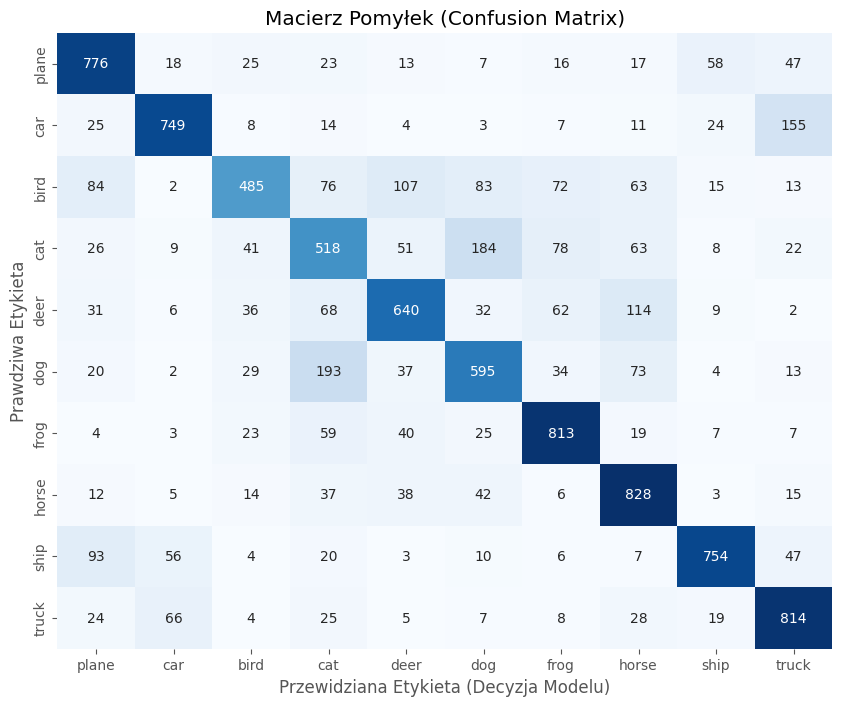

In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for data in test_loader:
        inputs, labels = data[0].to(device), data[1].to(device)
        outputs = model(inputs)
        
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("--- RAPORT KLASYFIKACJI ---")
print(classification_report(all_labels, all_preds, target_names=classes))

cm = confusion_matrix(all_labels, all_preds)

cm_df = pd.DataFrame(cm, index=classes, columns=classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Macierz Pomyłek (Confusion Matrix)')
plt.ylabel('Prawdziwa Etykieta')
plt.xlabel('Przewidziana Etykieta (Decyzja Modelu)')
plt.show()

5. Eksperymenty z Hiperparametrami

Zgodnie z wytycznymi, przeprowadzamy serie eksperymentów, zmieniając jeden hiperparametr przy stałych pozostałych. Aby to zautomatyzować i zapewnić wiarygodność wyników, każdy eksperyment inicjalizuje zupełnie nową instancję modelu CNN.


Seria 1: Wpływ współczynnika uczenia
Badamy wartości: 0.0001, 0.001, 0.01 oraz 0.1. Pozostałe parametry (Batch Size = 32, Optimizer = Adam) pozostają bez zmian.


--- Learning Rate: 0.0001 ---
  Epoka 1 Loss: 1.7855
  Epoka 2 Loss: 1.5013
  Epoka 3 Loss: 1.3823
  Epoka 4 Loss: 1.3055
  Epoka 5 Loss: 1.2478
  Końcowe Accuracy: 56.11%

--- Learning Rate: 0.001 ---
  Epoka 1 Loss: 1.3979
  Epoka 2 Loss: 1.0531
  Epoka 3 Loss: 0.9073
  Epoka 4 Loss: 0.8089
  Epoka 5 Loss: 0.7306
  Końcowe Accuracy: 68.27%

--- Learning Rate: 0.01 ---
  Epoka 1 Loss: 1.6978
  Epoka 2 Loss: 1.5736
  Epoka 3 Loss: 1.5189
  Epoka 4 Loss: 1.4914
  Epoka 5 Loss: 1.4786
  Końcowe Accuracy: 44.34%

--- Learning Rate: 0.1 ---
  Epoka 1 Loss: 2.5400
  Epoka 2 Loss: 2.3155
  Epoka 3 Loss: 2.3150
  Epoka 4 Loss: 2.3146
  Epoka 5 Loss: 2.3161
  Końcowe Accuracy: 10.00%


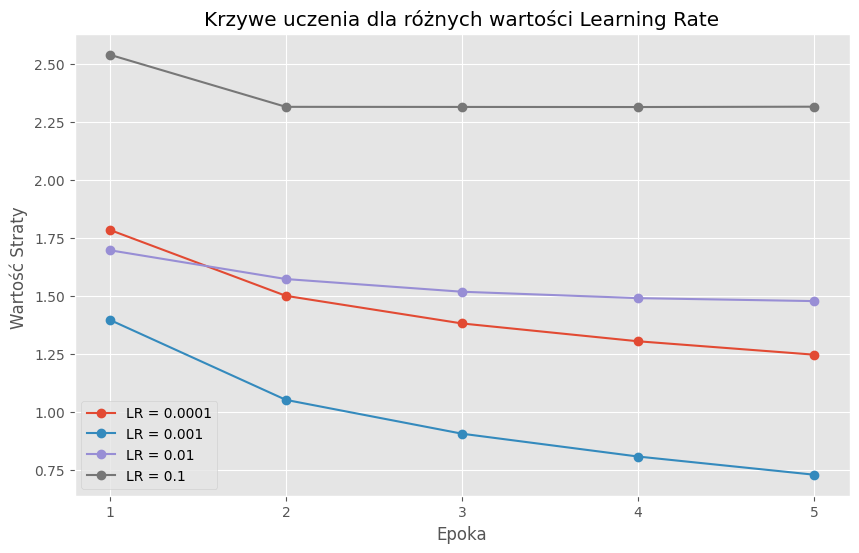


--- Podsumowanie Serii 1 w formie Tabeli ---


,Learning Rate,Test Accuracy (%)
0,0.0001,56.11
1,0.0010,68.27
2,0.0100,44.34
3,0.1000,10.00


In [9]:
import pandas as pd

learning_rates = [0.0001, 0.001, 0.01, 0.1]
all_train_losses = {}
results_table = []

epochs = 5


for lr_value in learning_rates:
    print(f"\n--- Learning Rate: {lr_value} ---")
    
    exp_model = SimpleCNN().to(device)
    exp_criterion = nn.CrossEntropyLoss()
    exp_optimizer = optim.Adam(exp_model.parameters(), lr=lr_value)
    
    losses_for_this_lr = []

    exp_model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            exp_optimizer.zero_grad()
            outputs = exp_model(inputs)
            loss = exp_criterion(outputs, labels)
            loss.backward()
            exp_optimizer.step()
            
            running_loss += loss.item()
            
        epoch_loss = running_loss / len(train_loader)
        losses_for_this_lr.append(epoch_loss)
        print(f"  Epoka {epoch+1} Loss: {epoch_loss:.4f}")
        
    all_train_losses[str(lr_value)] = losses_for_this_lr
    
    exp_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = exp_model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    final_accuracy = 100 * correct / total
    print(f"  Końcowe Accuracy: {final_accuracy:.2f}%")
    
    results_table.append({'Learning Rate': lr_value, 'Test Accuracy (%)': final_accuracy})

plt.figure(figsize=(10, 6))
for lr_name, losses in all_train_losses.items():
    plt.plot(range(1, epochs + 1), losses, marker='o', label=f'LR = {lr_name}')

plt.title('Krzywe uczenia dla różnych wartości Learning Rate')
plt.xlabel('Epoka')
plt.ylabel('Wartość Straty ')
plt.xticks(range(1, epochs + 1))
plt.legend()
plt.show()

print("\n--- Podsumowanie Serii 1 w formie Tabeli ---")
df_results = pd.DataFrame(results_table)
display(df_results)

Wnioski do Serii 1:

Jak wynika z powyższego wykresu oraz tabeli, współczynnik uczenia ma krytyczny wpływ na proces nauki modelu.

    - Zbyt wysoka wartość (lr = 0.1) uniemożliwia znalezienie minimum funkcji straty – model "skacze" po danych, co skutkuje bardzo niskim accuracy i brakiem spadku na krzywej uczenia.

    - Zbyt niska wartość (lr = 0.0001) sprawia, że proces optymalizacji jest bardzo powolny i wymagałby znacznie większej liczby epok.

    - Wartość optymalna (lr = 0.001) gwarantuje stabilny i szybki spadek błędu oraz najwyższe końcowe Accuracy.

Seria 2: Wpływ wielkości partii danych

W tym eksperymencie badamy wpływ ilości obrazów, które sieć przetwarza naraz przed każdą aktualizacją wag. Testujemy `batch_size` o wartościach 16, 32, 64 i 128. Aby badanie było rzetelne, za każdym razem musimy na nowo utworzyć obiekt `DataLoader`. W pozostałych parametrach stosujemy optymalną wartość Learning Rate równą 0.001 (zgodnie z wynikiem Serii 1).


--- Batch Size: 16 ---
  Epoka 1 Loss: 1.3180
  Epoka 2 Loss: 0.9764
  Epoka 3 Loss: 0.8327
  Epoka 4 Loss: 0.7272
  Epoka 5 Loss: 0.6380
  Końcowe Accuracy: 68.18%

--- Batch Size: 32 ---
  Epoka 1 Loss: 1.3898
  Epoka 2 Loss: 1.0422
  Epoka 3 Loss: 0.8960
  Epoka 4 Loss: 0.7962
  Epoka 5 Loss: 0.7135
  Końcowe Accuracy: 69.28%

--- Batch Size: 64 ---
  Epoka 1 Loss: 1.4170
  Epoka 2 Loss: 1.0770
  Epoka 3 Loss: 0.9340
  Epoka 4 Loss: 0.8315
  Epoka 5 Loss: 0.7456
  Końcowe Accuracy: 69.87%

--- Batch Size: 128 ---
  Epoka 1 Loss: 1.5286
  Epoka 2 Loss: 1.1811
  Epoka 3 Loss: 1.0296
  Epoka 4 Loss: 0.9343
  Epoka 5 Loss: 0.8565
  Końcowe Accuracy: 67.96%


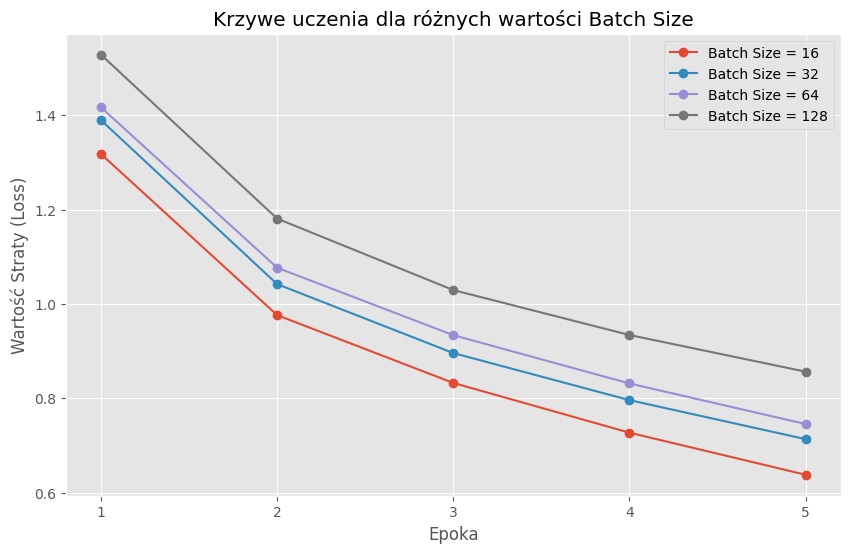


--- Podsumowanie Serii 2 w formie Tabeli ---


,Batch Size,Test Accuracy (%)
0,16,68.18
1,32,69.28
2,64,69.87
3,128,67.96


In [13]:
batch_sizes = [16, 32, 64, 128]
all_train_losses_s2 = {}
results_table_s2 = []

for b_size in batch_sizes:
    print(f"\n--- Batch Size: {b_size} ---")
    
    exp_train_loader = DataLoader(train_dataset, batch_size=b_size, shuffle=True)
    exp_test_loader = DataLoader(test_dataset, batch_size=b_size, shuffle=False)
    
    exp_model = DynamicCNN(kernel_size=3).to(device)
    exp_criterion = nn.CrossEntropyLoss()
    exp_optimizer = optim.Adam(exp_model.parameters(), lr=0.001)
    
    losses_for_this_batch = []
    
    exp_model.train()
    for epoch in range(5):
        running_loss = 0.0
        for inputs, labels in exp_train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            exp_optimizer.zero_grad()
            outputs = exp_model(inputs)
            loss = exp_criterion(outputs, labels)
            loss.backward()
            exp_optimizer.step()
            
            running_loss += loss.item()
            
        epoch_loss = running_loss / len(exp_train_loader)
        losses_for_this_batch.append(epoch_loss)
        print(f"  Epoka {epoch+1} Loss: {epoch_loss:.4f}")
        
    all_train_losses_s2[str(b_size)] = losses_for_this_batch
    
    exp_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in exp_test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = exp_model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    final_acc = 100 * correct / total
    print(f"  Końcowe Accuracy: {final_acc:.2f}%")
    results_table_s2.append({'Batch Size': b_size, 'Test Accuracy (%)': final_acc})

plt.figure(figsize=(10, 6))
for bs_name, losses in all_train_losses_s2.items():
    plt.plot(range(1, epochs + 1), losses, marker='o', label=f'Batch Size = {bs_name}')

plt.title('Krzywe uczenia dla różnych wartości Batch Size')
plt.xlabel('Epoka')
plt.ylabel('Wartość Straty (Loss)')
plt.xticks(range(1, epochs + 1))
plt.legend()
plt.show()

print("\n--- Podsumowanie Serii 2 w formie Tabeli ---")
df_results_s2 = pd.DataFrame(results_table_s2)
display(df_results_s2)

Wnioski dla serii 2:

Najlepsze rezultaty (~70%) osiągnięto przy Batch Size = 64.  
Mniejsze paczki (16, 32) przyspieszają początkową naukę, ale wprowadzają szum. Duże paczki (128) stabilizują trening, lecz spowalniają zbieżność, co przy 5 epokach dało słabszy wynik końcowy.

Seria 3: Wpływ rozmiaru filtra konwolucyjnego (Kernel Size)

W tej serii sprawdzimy, jak rozmiar filtra wpływa na proces ekstrakcji cech z obrazu. W tym celu zdefiniowaliśmy dynamiczną wersję naszej architektury CNN, która jako argument przyjmuje wielkość filtra. Używamy matematycznego triku z dodawaniem marginesu (`padding = kernel_size // 2`), aby niezależnie od wielkości "lupy" (3x3, 5x5, 7x7) wymiary aktywacji wpadających do warstwy w pełni połączonej były zawsze takie same. Pozostałe hiperparametry to optymalny `lr=0.001` oraz `batch_size=32`.

In [11]:
class DynamicCNN(nn.Module):
    def __init__(self, kernel_size):
        super(DynamicCNN, self).__init__()
        
        pad = kernel_size // 2 
        
        self.conv1 = nn.Conv2d(3, 16, kernel_size, padding=pad) 
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size, padding=pad) 
        
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10) 

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) 
        x = F.relu(self.fc1(x))
        x = self.fc2(x) 
        return x

kernel_sizes = [3, 5, 7]
all_train_losses_s3 = {} 
results_table_s3 = []    


for k_size in kernel_sizes:
    print(f"\n--- Kernel Size: {k_size}x{k_size} ---")
    
    exp_model = DynamicCNN(kernel_size=k_size).to(device)
    exp_criterion = nn.CrossEntropyLoss()
    exp_optimizer = optim.Adam(exp_model.parameters(), lr=0.001) 
    
    losses_for_this_k = []
    
    exp_model.train()
    for epoch in range(5):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            exp_optimizer.zero_grad()
            outputs = exp_model(inputs)
            loss = exp_criterion(outputs, labels)
            loss.backward()
            exp_optimizer.step()
            running_loss += loss.item()
            
        epoch_loss = running_loss / len(train_loader)
        losses_for_this_k.append(epoch_loss)
        print(f"  Epoka {epoch+1} Loss: {epoch_loss:.4f}")
        
    all_train_losses_s3[f"{k_size}x{k_size}"] = losses_for_this_k
    
    exp_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = exp_model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    final_acc = 100 * correct / total
    print(f"  Końcowe Accuracy: {final_acc:.2f}%")
    results_table_s3.append({'Kernel Size': f"{k_size}x{k_size}", 'Test Accuracy (%)': final_acc})


--- Kernel Size: 3x3 ---
  Epoka 1 Loss: 1.3906
  Epoka 2 Loss: 1.0400
  Epoka 3 Loss: 0.8739
  Epoka 4 Loss: 0.7718
  Epoka 5 Loss: 0.6848
  Końcowe Accuracy: 70.19%

--- Kernel Size: 5x5 ---
  Epoka 1 Loss: 1.3707
  Epoka 2 Loss: 1.0034
  Epoka 3 Loss: 0.8533
  Epoka 4 Loss: 0.7521
  Epoka 5 Loss: 0.6730
  Końcowe Accuracy: 69.59%

--- Kernel Size: 7x7 ---
  Epoka 1 Loss: 1.4048
  Epoka 2 Loss: 1.0468
  Epoka 3 Loss: 0.8847
  Epoka 4 Loss: 0.7687
  Epoka 5 Loss: 0.6742
  Końcowe Accuracy: 68.77%


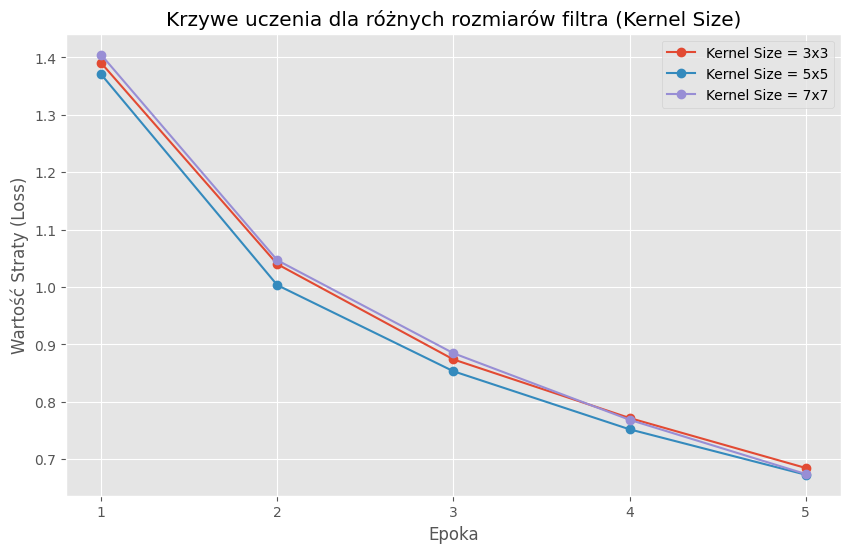


--- Podsumowanie Serii 3 w formie Tabeli ---


,Kernel Size,Test Accuracy (%)
0,3x3,70.19
1,5x5,69.59
2,7x7,68.77


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for ks_name, losses in all_train_losses_s3.items():
    plt.plot(range(1, 6), losses, marker='o', label=f'Kernel Size = {ks_name}')

plt.title('Krzywe uczenia dla różnych rozmiarów filtra (Kernel Size)')
plt.xlabel('Epoka')
plt.ylabel('Wartość Straty (Loss)')
plt.xticks(range(1, 6)) # Ponieważ ustawiliśmy 5 epok
plt.legend()
plt.show()

print("\n--- Podsumowanie Serii 3 w formie Tabeli ---")
df_results_s3 = pd.DataFrame(results_table_s3)
display(df_results_s3)

Wnioski do Serii 3:

Przeprowadzone badanie wpływu wielkości filtra konwolucyjnego wykazało, że ten parametr modyfikuje skuteczność sieci w sposób znacznie bardziej subtelny niż np. współczynnik uczenia.
W przeciwieństwie do ekstremalnych różnic zaobserwowanych przy błędnym dobraniu lr, tutaj każdy z modeli uczył się stabilnie.
Najwyższą dokładność na poziomie 70.19% uzyskał najmniejszy filtr 3x3. Filtry 5x5 (69.59%) oraz 7x7 (68.77%) uzyskały nieco słabsze wyniki.
Dla obrazów o małej rozdzielczości, takich jak te z bazy CIFAR-10 (32x32 piksele), mniejszy rozmiar filtra (3x3) okazuje się najbardziej efektywny. Pozwala on na precyzyjne wychwytywanie drobnych cech bez nadmiernego rozmywania detali, co może następować przy stosowaniu większych jąder konwolucyjnych (jak 7x7) na tak małej przestrzeni wejściowej.

6. Przykłady błędnie sklasyfikowanych obrazów

W tej sekcji dokonujemy wizualnej analizy skuteczności modelu poprzez wyświetlenie 10 przykładowych obrazów z zestawu testowego, które zostały błędnie sklasyfikowane. Proces ten obejmuje:  

    - Wyszukiwanie błędów: Model w trybie ewaluacji (model.eval()) przetwarza obrazy testowe bez obliczania gradientów (torch.no_grad()), a kod identyfikuje indeksy próbek, dla których przewidziana etykieta różni się od etykiety prawdziwej.  

    - Przygotowanie obrazów: Wyselekcjonowane obrazy są poddawane procesowi de-normalizacji (przywrócenie wartości pikseli do zakresu [0, 1]) oraz zmianie układu osi, aby biblioteka Matplotlib mogła je poprawnie wyświetlić.  

    - Wizualizacja: Każdy obraz jest podpisany czerwoną czcionką wskazującą decyzję modelu (P) oraz faktyczną klasę obiektu (T). Pozwala to ocenić, jakie cechy obrazu mogły wprowadzić sieć w błąd i czy pomyłki są uzasadnione (np. wizualne podobieństwo psa do kota).

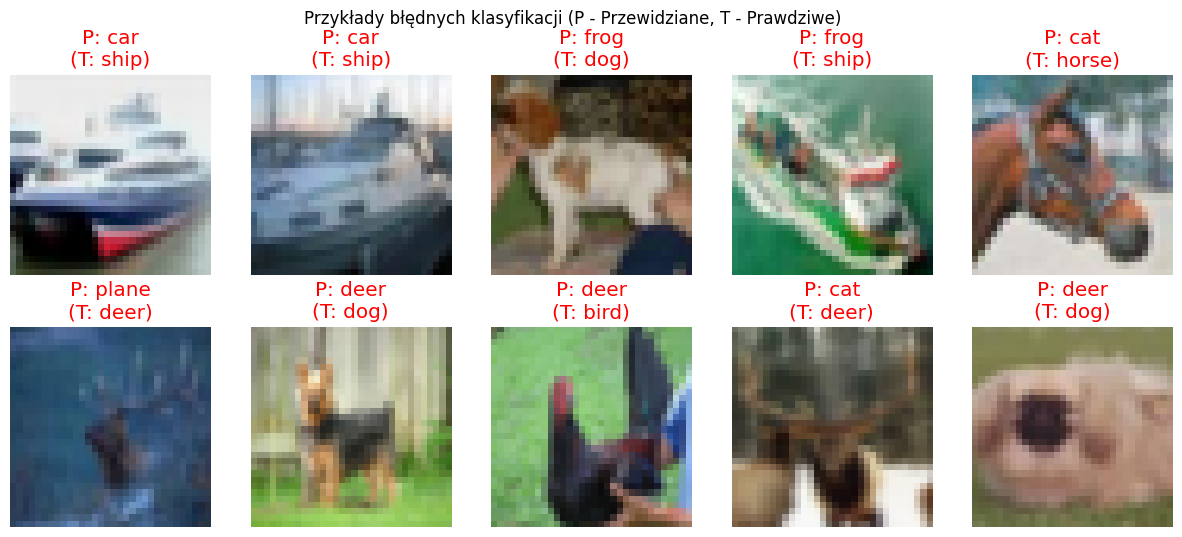

In [14]:

model.eval()
errors = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        incorrect_idx = (predicted != labels).nonzero(as_tuple=False)
        
        for idx in incorrect_idx:
            if len(errors) < 10: # Chcemy 10 przykładów
                errors.append((images[idx], predicted[idx], labels[idx]))
        if len(errors) >= 10: break

fig = plt.figure(figsize=(15, 6))
for i in range(len(errors)):
    img, pred, true = errors[i]
    img = img.squeeze().cpu() / 2 + 0.5 
    ax = fig.add_subplot(2, 5, i+1)
    plt.imshow(img.permute(1, 2, 0))
    ax.set_title(f"P: {classes[pred]}\n(T: {classes[true]})", color="red")
    plt.axis('off')
plt.suptitle("Przykłady błędnych klasyfikacji (P - Przewidziane, T - Prawdziwe)")
plt.show()